# <u>**k**-Nearest Neighbors Classifier</u>

## Topics

* [1. Core idea](#idea)
    
* [2. Distance Measures](#distance)
    * [2.1 Manhattan distance](#manhatten)
    * [2.2 Euclidean distance](#euclidean)

* [3. Prediction Methods](#methods)
    * [3.1 Regression](#reg)
        * <a href="../../1.Regression/6.k-Nearest Neighbors Regression/k-Nearest Neighbors Regression.ipynb">Check out the notebook on **k**-Nearest Neighbors Regression</a>
    * [**3.2 Classification**](#class)

    
* [4. Choosing **k** for Regression](#choose_k)
    * [4.1 Small **k**](#small_k)
    * [4.2 Large **k**](#large_k)

* [5. Choosing **k** for Classification](#choose_k2)
    * [4.1 Small **k**](#small_k2)
    * [4.2 Large **k**](#large_k2)

* [6. Model Characteristics](#model)
* [7. Limitations](#limits)
* [8. Feature Scaling & Weights](#scaling)
* [9. Gower distance](#gower)
* [10. Summary](#summary)

* [11. **k**-NN library implementation](#library)

In [1]:
import numpy as np # for rnadom number, linear algebra and general mathematic operations
import pandas as pd # for creating and working with dataframe
from matplotlib import pyplot as plt # for plotting in 2d
import plotly.express as px # for plotting in 3d
import plotly.graph_objects as go
from sklearn.neighbors import KNeighborsClassifier # for k-NN Classification
from sklearn.neighbors import NearestNeighbors # only find nearest neighbors
from scipy.spatial.distance import euclidean # euclidean distance
from scipy.spatial.distance import cityblock # manhatten distance
print("Setup complete")

Setup complete


<a class="anchor" id="idea"></a>
# 1. Core idea

- **k**-NN is a simple, non-parametric method used for:
    - Regression (predict numeric values)
    - Classification (predict categories)

- It works by:
    - Finding the **k** closest data points (<u>neighbors</u>) to a new point based on some distance measure
    - Making predictions based on those neighbors

We can define the **k**-neighborhood $N_{\text{k}}(x)$ of $x \in \mathbb{R}^p$ as the subset of data points $x^{(i)}$ that are at least as close to $x$ as its **k**-th closest neighbor $x^{(k)}$: $$N_{\text{k}}(x)=\{x^{(i)} \in \mathbb{R}^p \mid d(x^{(i)},x) \leq d(x^{(k)},x) \}$$

&#128073; It is a local model: Predictions depend only on nearby data.

<p align="center">
<img src="knn.jpeg" width="700"/>
</p>

<a class="anchor" id="distance"></a>
# 2. Distance Measures

To find "nearest" neighbors, distances are computed and for numerical features the **Minkowski** distance of the form 

$$
\lVert x - \tilde{x} \rVert_q = \left(\sum_{j=1}^p \mid x_j - \tilde{x}_j \mid^q \right)^{1/q}, \quad x \in \mathbb{R}^p \text{ and } \tilde{x} \in \mathbb{R}^p
$$

with $p$ being the number of features is often used.

<a class="anchor" id="manhatten"></a>
## 2.1 Manhattan distance 

For $q=1$ we get the Manhattan distance (L1):

$$
d_{\text{manhatten}}(x,\tilde{x})=\lVert x - \tilde{x} \rVert_1 = \left(\sum_{j=1}^p \mid x_j - \tilde{x}_j \mid^1 \right)^{1/1} = \sum_{j=1}^p \mid x_j - \tilde{x}_j \mid
$$

**It is the sum of absolute differences.**


In [2]:
def manhatten(x,x_new):
    x = np.array(x)
    x_new = np.array(x_new)
    return np.sum(np.abs(x-x_new))


<a class="anchor" id="euclidean"></a>
## 2.2 Euclidean distance

For $q=2$ we get the Euclidean distance (L2):

$$
d_{\text{euclidean}}(x,\tilde{x})=\lVert x - \tilde{x} \rVert_2 = \left(\sum_{j=1}^p \mid x_j - \tilde{x}_j \mid^2 \right)^{1/2} = \sqrt{\sum_{j=1}^p (x_j - \tilde{x}_j)^2}
$$

**It is the straight-line distance.**

In [3]:
def euclidean(x,x_new):
    return np.sqrt(np.sum((x-x_new)**2))

<p align="center">
<img src="Minkowski.jpeg" width="600"/>
</p>


&#128680; Important:
- Feature scales matter $\rightarrow$ large-scale features dominate distances
- Solution: Standardization/Normalization

<a class="anchor" id="methods"></a>
# 3. Prediction Methods

<a class="anchor" id="reg"></a>
## 3.1 &#128200; Regression

Predict by averaging the target values $y$ of the **k** neighbors in $N_{\text{k}}(x)$:

- Simple average 
$$
\hat{f}(x) = \frac{1}{\text{k}} \sum_{i:x^{(i)} \in N_{\text{k}}(x)} y^{(i)}
$$


- Weighted average (closer points get more weight) 
$$
\hat{f}(x) = \frac{1}{\sum_{i:x^{(i)} \in N_{\text{k}}(x)} w^{(i)}} \sum_{i:x^{(i)} \in N_{\text{k}}(x)} w^{(i)}y^{(i)}, \quad w^{(i)}=\frac{1}{d(x^{(i)},x)}
$$

<p align="center">
<img src="knn_reg.jpeg" width="700"/>
</p>


<a href="../../1.Regression/6.k-Nearest Neighbors Regression/k-Nearest Neighbors Regression.ipynb">Check out the notebook on **k**-Nearest Neighbors Regression for code.

<a class="anchor" id="choose_k"></a>
# 4. Choosing **k** for Regression

<a class="anchor" id="small_k"></a>
## 4.1 Small **k** (e.g., 1-3)
**Low bias but high variance**:
- Low bias: Can fit complex patterns
- High variance: Predictions vary a lot since they rely on very few neighbors
- Predictions are very sensitive to noise
- The regression curve becomes wiggly / highly flexible
- In extreme case **k**=1: Prediction is just the value of the nearest neighbor $\rightarrow$ can be very noisy.
- Small **k** $\rightarrow$ "listen to closest voices" $\rightarrow$ noisy but detailed

<a class="anchor" id="large_k"></a>
## 4.2 Large **k**
**Low variance but high bias**:
- High bias: Misses local structure
- Low variance: Predictions vary less since they rely on many neighbors
- The model averages over many points
- In extreme case **k**=n: Predict the global mean of all targets $\rightarrow$ no local adaptation at all.
- Predictions become very smooth

- Large **k** $\rightarrow$ "listen to the crowd" $\rightarrow$ smooth but less precise

&#128073; Trade-off: Bias vs Variance

<p align="center">
<img src="bias_variance_reg.jpeg" width="550"/>
</p>



<a class="anchor" id="class"></a>
## 3.2 &#128278; Classification

* Predict by majority vote among neighbors for classification in $g$ groups
$$
\hat{h}(x)=\underset{l \in \{1,2,\ldots,g\}}{\arg\max} \sum_{i:x^{(i)} \in N_{\text{k}}(x)} \mathbb{I}(y^{(i)} = l)
$$


* Estimate posterior probabilities as proportion of neighbors in each class
$$
\hat{\pi}_l(x)=\frac{1}{\text{k}} \sum_{i:x^{(i)} \in N_{\text{k}}(x)} \mathbb{I}(y^{(i)} = l)
$$

<p align="center">
<img src="knn_class.jpeg" width="700"/>
</p>




 k = 3 
Prediction: 3
Posteriors: {np.int64(1): 0.3333333333333333, np.int64(2): 0.0, np.int64(3): 0.6666666666666666}

 k = 10 
Prediction: 1
Posteriors: {np.int64(1): 0.6, np.int64(2): 0.0, np.int64(3): 0.4}


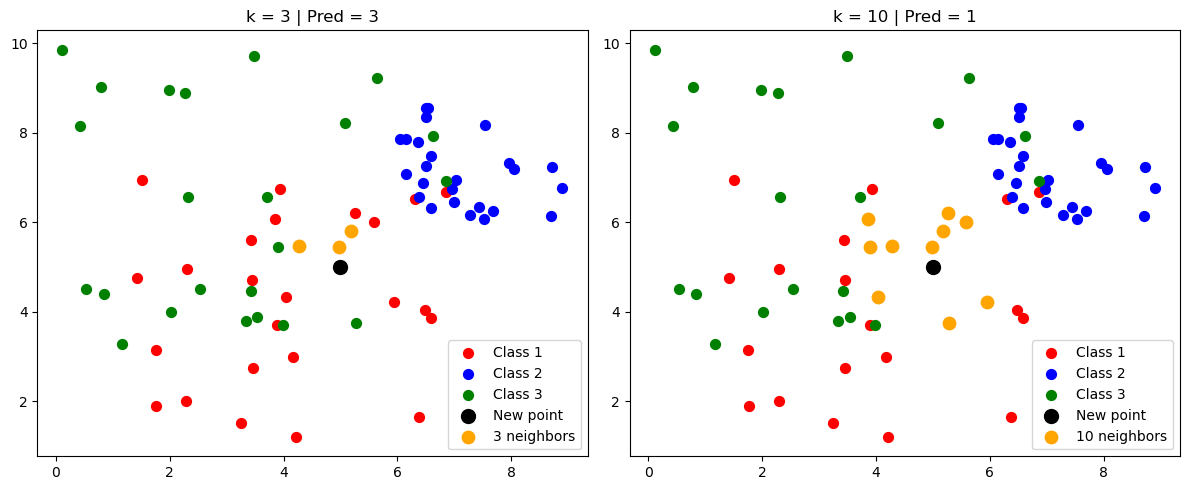

In [4]:
def knn_predict(X, y, new_data, k):
    distances = [(i, euclidean(x, new_data)) for i, x in enumerate(X)]
    distances.sort(key=lambda x: x[1])

    k_distances = distances[:k]

    k_neighbors_classes = [y[i[0]] for i in k_distances]
    k_neighbors = np.array([X[i[0]] for i in k_distances])

    classes = np.unique(y)

    # class counts
    counts = {}
    for c in classes:
        counts[c] = k_neighbors_classes.count(c)

    # posterior probabilities
    posteriors = {c: counts[c] / k for c in classes}

    # prediction
    prediction = max(counts, key=counts.get)

    return prediction, posteriors, k_neighbors, k_distances


# Data 
np.random.seed(1154)
n = 25

X_class1 = np.random.uniform(1, 7, (n, 2))
X_class2 = np.random.uniform(6, 9, (n, 2))
X_class3 = np.column_stack((np.random.uniform(0, 7, n),np.random.uniform(3, 10, n)))

X = np.vstack((X_class1, X_class2, X_class3))
y = np.array([1]*25 + [2]*25 + [3]*25)

new_data = np.array([5, 5])


# Plot 
ks = [3, 10]

plt.figure(figsize=(12, 5))

for idx, k in enumerate(ks):
    prediction, posteriors, k_neighbors, k_distances = knn_predict(X, y, new_data, k)

    print(f"\n k = {k} ")
    print("Prediction:", prediction)
    print("Posteriors:", posteriors)

    ax = plt.subplot(1, 2, idx + 1)

    # Data points
    ax.scatter(X[y==1][:,0], X[y==1][:,1], color="red", label="Class 1", s=50)
    ax.scatter(X[y==2][:,0], X[y==2][:,1], color="blue", label="Class 2", s=50)
    ax.scatter(X[y==3][:,0], X[y==3][:,1], color="green", label="Class 3", s=50)

    # new point
    ax.scatter(new_data[0], new_data[1], color="black", label="New point", s=100)

    # neighbors
    ax.scatter(k_neighbors[:,0], k_neighbors[:,1], color="orange", label=f"{k} neighbors", s=80)

    ax.set_title(f"k = {k} | Pred = {prediction}")
    ax.legend()

plt.tight_layout()
plt.show()

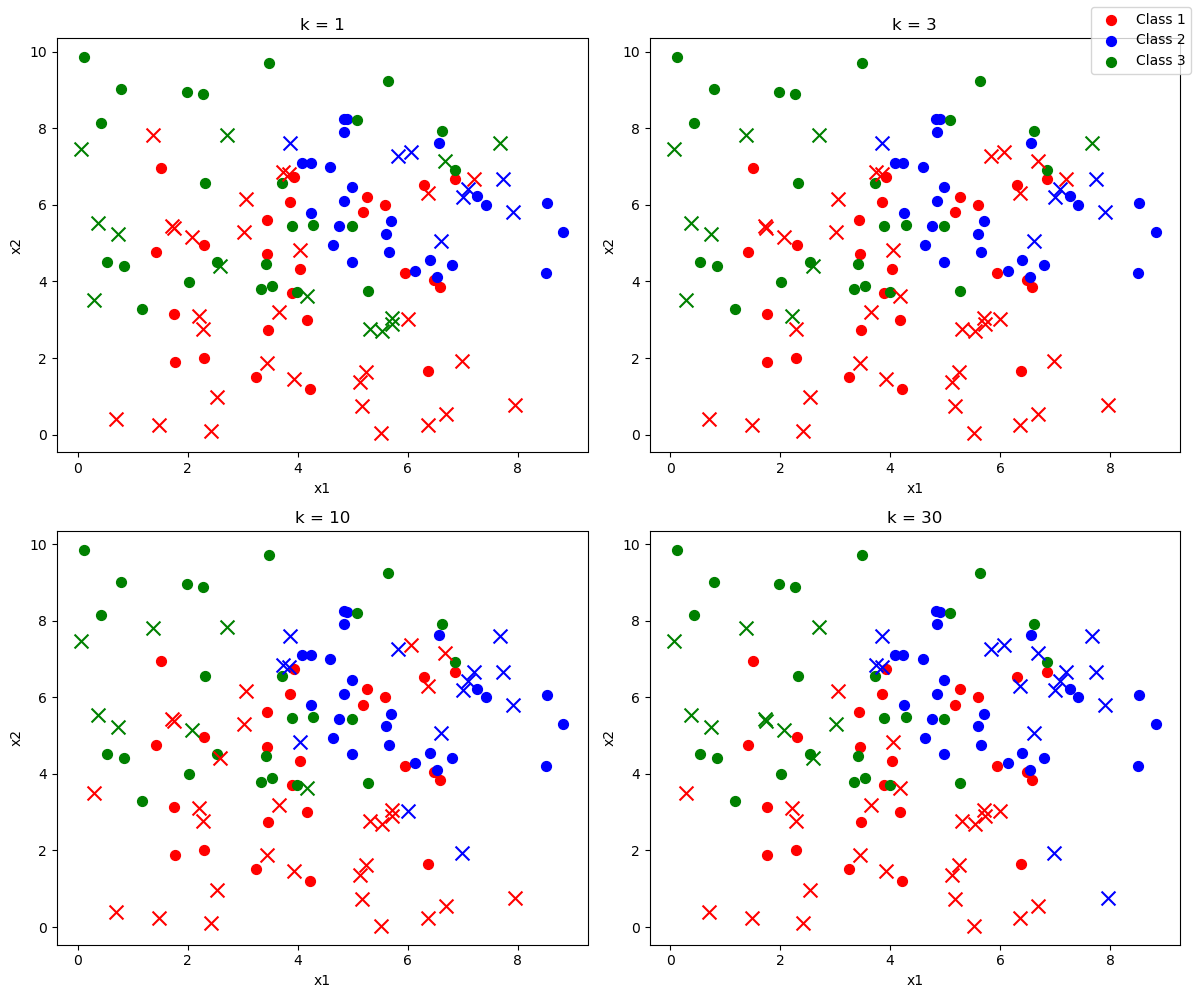

In [6]:
# Data
np.random.seed(1154)
n = 25

X_class1 = np.random.uniform(1, 7, (n, 2))
X_class2 = np.random.uniform(4, 9, (n, 2))
X_class3 = np.column_stack((np.random.uniform(0, 7, n),np.random.uniform(3, 10, n)))

X = np.vstack((X_class1, X_class2, X_class3))
y = np.array([1]*n + [2]*n + [3]*n)

new_data = np.random.uniform(0, 8, (n*2, 2)) # new data ponits


# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ks = [1, 3, 10, 30]

axes = axes.ravel()  # flatten to 1D array

for ax, k in zip(axes, ks):

    ax.scatter(X[y==1][:,0], X[y==1][:,1], color="red", label="Class 1", s=50)
    ax.scatter(X[y==2][:,0], X[y==2][:,1], color="blue", label="Class 2", s=50)
    ax.scatter(X[y==3][:,0], X[y==3][:,1], color="green", label="Class 3", s=50)

    for x in new_data:
        prediction, _, _, _ = knn_predict(X, y, x, k) 

        if prediction == 1:
            color = "red"
        elif prediction == 2:
            color = "blue"
        else:
            color = "green"

        ax.scatter(x[0], x[1], marker="x", color=color,s=100)

    ax.set_title(f"k = {k}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    #ax.legend()

# one global legend (cleaner) (leave ax.legend() outcommented)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()


In [ ]:
np.random.seed(2022)
n = 50

X_class1 = np.random.uniform(0, 12, (n, 3))
X_class2 = np.random.uniform(9, 20, (n, 3))
X_class3 = np.column_stack([np.random.uniform(0, 8, n),np.random.uniform(0, 15, n),np.random.uniform(8, 17, n)])

X = np.vstack((X_class1, X_class2, X_class3))
y = np.array([1]*n + [2]*n + [3]*n)

new_data = np.random.uniform(5, 8, (1, 3))
k=2

prediction, posteriors, k_neighbors, k_distances = knn_predict(X, y, new_data[0], k)

fig = px.scatter_3d(x=X[:,0], y=X[:,1], z=X[:,2],color=y.astype(str),title="k-NN 3D Visualization")

# color mapping
color_map = {1: "red",2: "blue",3: "green"}

# new data
fig.add_trace(
    go.Scatter3d(
        x=[new_data[0,0]],y=[new_data[0,1]],z=[new_data[0,2]],
        mode="markers",
        marker=dict(size=8,color=color_map[prediction],symbol="diamond"),
        name=f"New Point (Class {prediction})"))

# k nearest neighbors
fig.add_trace(
    go.Scatter3d(
        x=k_neighbors[:,0], y=k_neighbors[:,1],z=k_neighbors[:,2],
        mode="markers",
        marker=dict(size=6,color="yellow",symbol="circle"),
        name=f"{k} Nearest Neighbors"))

fig.show()


<a class="anchor" id="choose_k"></a>
# 4. Choosing **k** for Regression

<a class="anchor" id="small_k"></a>
## 4.1 Small **k** (e.g., 1-3)
**Low bias but high variance**:
- Low bias: Can fit complex patterns
- High variance: Predictions vary a lot since they rely on very few neighbors
- Predictions are very sensitive to noise
- The regression curve becomes wiggly / highly flexible
- In extreme case **k**=1: Prediction is just the value of the nearest neighbor $\rightarrow$ can be very noisy.
- Small **k** $\rightarrow$ "listen to closest voices" $\rightarrow$ noisy but detailed

<a class="anchor" id="large_k"></a>
## 4.2 Large **k**
**Low variance but high bias**:
- High bias: Misses local structure
- Low variance: Predictions vary less since they rely on many neighbors
- The model averages over many points
- In extreme case **k**=n: Predict the global mean of all targets $\rightarrow$ no local adaptation at all.
- Predictions become very smooth

- Large **k** $\rightarrow$ "listen to the crowd" $\rightarrow$ smooth but less precise

&#128073; Trade-off: Bias vs Variance

<p align="center">
<img src="bias_variance_reg.jpeg" width="550"/>
</p>



<a class="anchor" id="choose_k2"></a>
# 5. Choosing **k** for Classification

<a class="anchor" id="small_k2"></a>
## 5.1 Small **k** (e.g., 1-3)

**Low bias but high variance**:
- Low bias: New data points often get classified correctly
- High variance: New data points get classified based on very few neighbors resulting in often different classes for new data points in close proximity
- Sensitive to noise/outliers: Outliers can influence class of new data points more easily
- Very flexible and "wiggly" decision boundaries




<a class="anchor" id="large_k2"></a>
## 5.2 Large **k**
**Low variance but high bias**
- High bias: New data points get missclassified more often
- Low variance: New data points get classified based on many neighbors resulting in predictions based on the dominant class in that proximity (may miss local patterns)
- Less sensitive no noise/outliers: Outlier now carry weaker influence since they are in the minority
- More stable and "smooth" decision boundaries


&#128073; Trade-off: Bias vs Variance

<p align="center">
<img src="bias_variance.jpeg" width="550"/>
</p>

<a class="anchor" id="model"></a>
# 6. Model Characteristics

Lazy learning:
- No real training phase
- Stores all training data

Non-parametric:
- Parameters of **k**-NN are the training data
- Model complexity grows with data

No assumptions:
- **k**-NN is not based on distributions 
- Can model very complex patterns 

<a class="anchor" id="limits"></a>
# 7. Limitations

* Sensitive to:
    - Noisy data
    - Irrelevant features/ High dimensional data points
    - Different feature scales
    - Class imbalance for **k**-NN for Classifier
        - Example: If 90% of data is class A $\rightarrow$ prediction biased toward A
        - Fix: weighted voting or resampling

* Computationally expensive for large datasets

* Requires careful choice of **k** and distance metric  $d(x,\tilde{x})$

<a class="anchor" id="scaling"></a>
# 8. Feature scaling & Weights

Standardization
- Features should be standardized or normalized
- Example $(x_1,x_2)$: If $x_1 \in \underbrace{\{0,1000\}}_{\text{large scale}}$ and $x_2 \in  \underbrace{\{0,10\}}_{\text{small scale}}$ then most distance metrics would place higher importance on $x_1$.


Importance
- Assign weights to features if some are more important (i.e. weighted euclidean distance)
$$
d_{\text{euclidean}}^{\text{weighted}}(x,\tilde{x})=\sqrt{\sum_{j=1}^p w_j(x_j - \tilde{x}_j)^2}
$$

```python
from sklearn.preprocessing import StandardScaler # used to standardize features by removing the mean and scaling to unit variance

X = np.array([[1, 2], [3, 4], [5, 6]]) # data matrix of shape (n_samples, n_features)
# array([[1, 2],
#       [3, 4],
#       [5, 6]])

scaler = StandardScaler(copy=True,with_mean=True,with_std=True) # create a sklearn.preprocessing._data.StandardScaler object
# with_mean -> Whether centering is applied
# with_std -> Whether scaling is applied
# copy -> Copy or in-place transform

scaler.fit(X) # Standarscaler learns the statistics of X and computes mean and variance/std of each feature

scaler.mean_ # returns an arry of shape (n_features,) with the mean of each feature (only available if with_mean=True)
scaler.var_ # returns an arry of shape (n_features,) with the variance of each feature (Used to compute the standard deviation)
scaler.scale_ # returns an arry of shape (n_features,) with the standard deviation (only available if with_std=True and if variance is zero then scale is set to 1 to avoid division by zero)
scale.n_features_in_ # number of features seen during fit()
scale.feature_names_in_ # returns an arry of shape (n_features,) with names of features (only if input has column names, e.g. pandas DataFrame)
scale.n_samples_seen_ # Number of samples processed
X_scaled = scaler.transform(X) # applies standardization: X_scaled = (X - mean_) / scale_
X_scaled = scaler.fit_transform(X) # shortcut
```

<a class="anchor" id="gower"></a>
# 9. Gower distance

Used when data includes:
- Mixed types (numerical + categorical)
- Missing values

Key ideas:
- Combines feature-wise distances
- Handles:
    - categorical (match/mismatch)
    - numerical (scaled differences)
- Ignores missing values in comparisons

$$
d_{\text{gower}}(x,\tilde{x}) = \frac{\sum_{j=1}^p \delta_{x_j,\tilde{x}_j} \cdot d_{\text{gower}}(x_j,\tilde{x}_j)}{\sum_{j=1}^p \delta_{x_j,\tilde{x}_j} }
$$

$$
\delta_{x_j,\tilde{x}_j}=
\begin{cases}
0 &, \text{if } j\text{-th feature is missing in at least one observation} \\
& \text{ or if feature is asymmetric binary and both values are zero} 
\\ 
1 &, \text{otherwise} \\
\end{cases}
$$

Features are asymmetric binary if "1" is more important than "0". 

For categoricals:
$$
d_{\text{gower}}(x_j,\tilde{x}_j)=
\begin{cases}
0 &, \text{ if  both values are equal}
\\ 
1 &, \text{otherwise} \\
\end{cases}
$$


For integers and numericals:
$$
d_{\text{gower}}(x_j,\tilde{x}_j)= \text{ absolute difference}
$$

**Example:**

$$
\begin{array}{c|c|c}
 & \text{sex} & \text{salary} \\
\hline
1 & m & 2340 \\
2 & w & 2100 \\
3 & \text{NA} & 2680 \\
\end{array}
$$

$$
d_{\text{gower}}(x^{(1)}, x^{(2)}) =
\frac{1 \cdot 1 + 1 \cdot \frac{\mid 2340 - 2100 \mid}{\mid 2680 - 2100 \mid}}{1 + 1}=\frac{1 + \frac{240}{580}}{2}= 0.707
$$

$$
d_{\text{gower}}(x^{(1)}, x^{(3)}) =\frac{0 \cdot 1 + 1 \cdot \frac{\mid 2340 - 2680 \mid}{\mid 2680 - 2100 \mid}}{0 + 1}=\frac{\frac{340}{580}}{1}=0.586
$$

$$
d_{\text{gower}}(x^{(2)}, x^{(3)}) =\frac{0 \cdot 1 + 1 \cdot \frac{\mid 2100 - 2680 \mid}{\mid 2680 - 2100 \mid}}{0 + 1}=\frac{\frac{580}{580}}{1}=1
$$

<a class="anchor" id="summary"></a>
# 10. Summary

* **k**-NN is simple but powerful
* Works well for nonlinear problems
* Performance depends heavily on:
    * choice of **k**
    * distance metric
    * feature preprocessing

<a class="anchor" id="library"></a>
# 11. **k**-NN library implementation

```python
# 1. k-NN (scikit-learn)
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

# Regression 
model1_reg = KNeighborsRegressor(
    n_neighbors=5,
    weights="uniform",
    algorithm="auto",
    p=2,
    metric="minkowski"
)

model1_reg.fit(X, y)

model1_reg.predict(X) # predicted values
model1_reg.score(X, y) # R^2 score

# Classification 
model1 = KNeighborsClassifier(
    n_neighbors=5, # k (number of neighbors)
    weights="uniform", # "uniform" or "distance"
    algorithm="auto", # "auto", "ball_tree", "kd_tree", "brute"
    leaf_size=30, # tree parameter (for ball_tree / kd_tree)
    p=2, # distance metric power (p=2 -> Euclidean)
    metric="minkowski", # distance metric
    n_jobs=None # parallel jobs (-1 = use all cores)
)

model1.fit(X, y) # store training data (lazy learning)

model1.predict(X) # predicted class labels
model1.predict_proba(X) # class probabilities
model1.score(X, y) # accuracy
model1.kneighbors(X) # distances + indices of nearest neighbors


# 2. k-NN with Cross-Validation (Grid Search)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_neighbors": range(1, 21), # candidate k values
    "weights": ["uniform", "distance"],
    "p": [1, 2] # Manhattan vs Euclidean
}

model2 = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5, # k-fold CV
    n_jobs=-1
)

model2.fit(X, y)

model2.best_params_ # best hyperparameters
model2.best_score_ # best CV score
model2.best_estimator_


# 3. Distance-based usage (manual neighbor queries)
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(
    n_neighbors=5,
    algorithm="auto",
    metric="minkowski",
    p=2
)

nn.fit(X)

distances, indices = nn.kneighbors(X) # nearest neighbors


# 4. k-NN with precomputed distance matrix
from sklearn.neighbors import KNeighborsClassifier

model4 = KNeighborsClassifier(
    n_neighbors=5,
    metric="precomputed" # use custom distance matrix
)

model4.fit(D_train, y) # D_train = distance matrix
model4.predict(D_test)


# 5. Using FAISS (fast large-scale k-NN, GPU optional)
import faiss
import numpy as np

X_np = np.array(X).astype("float32")

index = faiss.IndexFlatL2(X_np.shape[1]) # L2 distance
index.add(X_np) # add dataset

k = 5
distances, indices = index.search(X_np, k) # k-NN search


# 6. Using Annoy (approximate nearest neighbors)
from annoy import AnnoyIndex

f = X.shape[1]  # number of features
index = AnnoyIndex(f, "euclidean")

for i, v in enumerate(X.values):
    index.add_item(i, v)

index.build(10) # number of trees

indices = index.get_nns_by_vector(X.iloc[0].values, 5)
```

In [ ]:
# Simple toy dataset
X = np.array([
    [25, 50000],
    [30, 60000],
    [35, 65000],
    [40, 80000],
    [45, 90000]
])

y = np.array([0, 0, 1, 1, 1])  # class labels

# New observation
X_new = np.array([[33, 62000]])


model = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance", # closer neighbors matter more
    p=2 # Euclidean distance
)

model.fit(X, y)

# Prediction
pred = model.predict(X_new)
proba = model.predict_proba(X_new)

print("Predicted class:", pred)
print("Class probabilities:", proba)

# %%
distances, indices = model.kneighbors(X_new)

print("Neighbor indices:", indices)
print("Neighbor distances:", distances)
print("Neighbor labels:", y[indices])



nn = NearestNeighbors(
    n_neighbors=3,
    metric="euclidean"
)

nn.fit(X)

distances, indices = nn.kneighbors(X_new)

print("Nearest neighbor indices:", indices)
print("Distances:", distances)
print("Neighbor points:\n", X[indices])

Predicted class: [0]
Class probabilities: [[0.63636346 0.36363654]]
Neighbor indices: [[1 2 0]]
Neighbor distances: [[ 2000.00225     3000.00066667 12000.00266667]]
Neighbor labels: [[0 1 0]]
Nearest neighbor indices: [[1 2 0]]
Distances: [[ 2000.00225     3000.00066667 12000.00266667]]
Neighbor points:
 [[[   30 60000]
  [   35 65000]
  [   25 50000]]]
